# Imports and pre-processing

<div class='alert alert-warning'>

**N.B:** This section **does not contain** the imports specific for the Optical Flow part for they are specific to GPU-enabled environments

</div>

In [ ]:
import pandas as pd
import ffmpeg
import os
import glob
from scenedetect import open_video, SceneManager, StatsManager
from scenedetect.detectors import ContentDetector
from tqdm import tqdm
from transformers import pipeline, Wav2Vec2Processor
import cv2
import pytesseract
from PIL import Image
from IPython.display import display

import torch
import librosa
from moviepy.editor import VideoFileClip
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from transformers.models.wav2vec2.modeling_wav2vec2 import (
    Wav2Vec2Model,
    Wav2Vec2PreTrainedModel,
)

# Check if GPU is available
device = 0 if torch.cuda.is_available() else -1
print(f"Using device: {'GPU (T4)' if device == 0 else 'CPU'}")

In [ ]:
df_train = pd.read_csv('data/X_train.csv', sep=';', header=0)
df_test = pd.read_csv('data/X_test.csv', sep=';', header=0)

df_train["split"] = "train"
df_test["split"] = "test"

df = pd.concat([df_train, df_test], ignore_index=True)
df = df[["id", "filepath", "split"]]
df['filepath'] = df['filepath'].str.replace('downloads/', 'data/videos_mp4/', regex=False)

In [ ]:
df.head()

,id,filepath,split
0,7602656035161050390,data/videos_mp4/USER_davosklosters/VIDEO_76026...,train
1,7590718903144287510,data/videos_mp4/USER_davosklosters/VIDEO_75907...,train
2,7571821778746592534,data/videos_mp4/USER_davosklosters/VIDEO_75718...,train
3,7569927329154190614,data/videos_mp4/USER_davosklosters/VIDEO_75699...,train
4,7566270741134462230,data/videos_mp4/USER_davosklosters/VIDEO_75662...,train


# Good hook detection

In [22]:
def trim_video_hook(input_path, output_path, hook_duration_sec=2.0):
    """
    Trims a single video to the specified duration.
    """
    try:
        (
            # We don't use stream copy (-c copy) because we want frame-perfect 
            # cuts for ML analysis, even if it requires a quick re-encode.
            ffmpeg
            .input(input_path)
            .output(output_path, t=hook_duration_sec)
            .overwrite_output()
            .run(capture_stdout=True, capture_stderr=True)
        )
        return True
    except ffmpeg.Error as e:
        print(f"Failed to trim {input_path}")
        # ffmpeg errors are stored in stderr; we decode it to see the actual problem
        print(e.stderr.decode('utf8'))
        return False

def batch_process_hooks(input_dir, output_dir, hook_duration_sec=2.0):
    """
    Scans a directory for MP4s and saves the 2-second hooks into an output folder.
    """
    # Create the output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Find all mp4 files in the input directory
    # Use ** to look through any number of subdirectories
    search_pattern = os.path.join(input_dir, "**", "*.mp4")
    video_files = glob.glob(search_pattern, recursive=True)
    
    print(f"Found {len(video_files)} videos. Starting batch trim...")
    
    success_count = 0
    for video_path in tqdm(video_files):
        filename = os.path.basename(video_path)
        output_path = os.path.join(output_dir, f"hook_{filename}")
        
        if trim_video_hook(video_path, output_path, hook_duration_sec):
            success_count += 1
            
    print(f"Batch complete! Successfully trimmed {success_count}/{len(video_files)} videos.")

In [23]:
RAW_VIDEOS_FOLDER = "data/videos_mp4/"
TRIMMED_HOOKS_FOLDER = "processed_hooks"

batch_process_hooks(RAW_VIDEOS_FOLDER, TRIMMED_HOOKS_FOLDER, hook_duration_sec=2.0)

Found 1686 videos. Starting batch trim...


100%|██████████| 1686/1686 [30:38<00:00,  1.09s/it]

Batch complete! Successfully trimmed 1686/1686 videos.


## Cut/Edit Frequency - Content score mean and max

**PySceneDetect** calculates the "Content Score" by looking at the exact same $(x, y)$ pixel coordinate in Frame A and Frame B, and subtracting the color values.

**What it misses:**
It has zero concept of motion. It doesn't know the red ball *moved* to the right. It just knows that pixel $(50, 50)$ used to be red and is now black.

Because of this, **Average Volatility is highly sensitive to lighting changes and camera cuts.** If a creator turns on a strobe light, or applies a heavy color filter in the first second of the video, the Volatility Score will skyrocket, even if nothing on screen actually physically moved.

In [29]:
def get_hook_intensity_features(video_path):
    """
    Analyzes a video clip to extract raw frame-differencing metrics.
    Returns the maximum cut intensity and the average visual volatility.
    """
    try:
        video = open_video(video_path)
        stats_manager = StatsManager() # Track frame-by-frame metrics
        
        scene_manager = SceneManager(stats_manager=stats_manager)
        scene_manager.add_detector(ContentDetector())
        
        scene_manager.detect_scenes(video)
        
        # Extract the raw 'content_val' scores from the StatsManager
        # 'content_val' is the HSV delta score between consecutive frames.
        frame_metrics = []
        frame_num = 1
        
        while stats_manager.metrics_exist(frame_num, ['content_val']):
            # get_metrics returns a list of values in the order requested
            metrics = stats_manager.get_metrics(frame_num, ['content_val'])
            
            if metrics and metrics[0] is not None:
                frame_metrics.append(metrics[0])
                
            frame_num += 1
                
        # Calculate features
        if not frame_metrics:
            return -1, -1  # Fallback if the video is completely corrupted/empty
            
        max_intensity = max(frame_metrics)
        avg_volatility = sum(frame_metrics) / len(frame_metrics)
        
        return max_intensity, avg_volatility

    except Exception as e:
        print(f"Error processing {video_path}: {e}")
        return -1, -1 

In [32]:
cut_metrics = []

for video_path in tqdm(glob.glob(os.path.join(TRIMMED_HOOKS_FOLDER, "*.mp4"))):
    max_spike, avg_vol = get_hook_intensity_features(video_path)

    filename = os.path.basename(video_path)
    id = filename.replace("hook_VIDEO_", "").replace(".mp4", "")
    cut_metrics.append((int(id), max_spike, avg_vol))

100%|██████████| 1686/1686 [06:00<00:00,  4.68it/s]


In [33]:
results_df = pd.DataFrame(cut_metrics, columns=['id', 'max_spike', 'avg_volatility'])
df = df.merge(results_df, on='id', how='left')

## Immediate On-Screen Text

Use **Pytesseract** on frame 15 (0.5 seconds in) to extract the text present in the video, returning `None` if there isn't any.

Then, apply a **Multilingual Zero-Shot Classifier** to evaluate if the text is "catchy" or sort of clickbait or not, returning the confidence level.

### Text extraction

In [ ]:
def nb_imshow(frame, title=None):
    """
    Direct substitute for cv2.imshow in Jupyter Notebooks.
    Converts BGR to RGB and displays inline.
    """
    if title:
        print(f"--- {title} ---")
    
    # 1. OpenCV uses BGR, but web/PIL use RGB. Must convert.
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # 2. Convert the numpy array to a PIL Image object
    img = Image.fromarray(frame_rgb)
    
    # 3. Use IPython's display to render it inline
    display(img)

In [109]:
def extract_text_from_frame(video_path, target_frame=15, psm_mode=3):
    """
    Jumps to a specific frame in a video, converts it to grayscale, 
    and uses OCR to extract any on-screen text.
    Returns the cleaned text string, or None if no text is found.
    """
    cap = cv2.VideoCapture(video_path)
    
    # Check if video opened successfully
    if not cap.isOpened():
        return None

    # Jump straight to the target frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        return None # Frame didn't exist (video might be too short)

    # Preprocessing: Convert to grayscale for better OCR accuracy
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # Binary threshold for contrast
    _, thresh_frame = cv2.threshold(gray_frame, 150, 255, cv2.THRESH_BINARY)

    # Extract text using Tesseract
    extracted_text = pytesseract.image_to_string(thresh_frame, config=f'--psm {psm_mode}')
    
    # Clean up the string (remove extra newlines and whitespace)
    clean_text = extracted_text.strip()
    
    # Return None if the string is empty, otherwise return the text
    if len(clean_text) == 0:
        return None
    else:
        # Replace newlines with spaces so it fits nicely in a CSV cell
        return clean_text.replace('\n', ' ')

def batch_process_text(video_folder, target_frame=15, psm_mode=3):
    """
    Iterates through the trimmed clips to find text hooks.
    """
    video_files = sorted(glob.glob(os.path.join(video_folder, "*.mp4")))
    if not video_files:
        print("No videos found.")
        return []

    text_results = []
    
    with tqdm(total=len(video_files), desc="Extracting Text Hooks") as pbar:
        for video_path in video_files:
            text_found = extract_text_from_frame(video_path, target_frame, psm_mode=3)
            
            # Clean ID for merging later
            video_id = os.path.basename(video_path).replace("hook_VIDEO_", "").replace(".mp4", "")
            
            text_results.append({
                'video_id': int(video_id),
                'has_text': 1 if text_found is not None else 0, # Binary feature for ML
                'extracted_text': text_found                    # The actual text (or None)
            })
            pbar.update(1)
            
    return text_results    

In [110]:
text_metrics = batch_process_text(TRIMMED_HOOKS_FOLDER, target_frame=15, psm_mode=4) #try 12 and 13
    
# Convert to DataFrame
text_df_bin = pd.DataFrame(text_metrics)
print(f"\nFound text in {text_df_bin['has_text'].sum()} out of {len(text_df_bin)} videos.")

Extracting Text Hooks: 100%|██████████| 1686/1686 [07:36<00:00,  3.69it/s]


Found text in 586 out of 1686 videos.


In [133]:
text_df_bin[text_df_bin["has_text"]==1].count()

video_id          586
has_text          586
extracted_text    586
dtype: int64

#### Image preprocessing experiments for Tesseract debugging

In [78]:
vid = 7054964457310539013
filename = f"hook_VIDEO_{vid}.mp4"
video_path = os.path.join(TRIMMED_HOOKS_FOLDER, filename)

In [79]:
cap = cv2.VideoCapture(video_path)
cap.isOpened()

True

In [80]:
# Jump straight to the target frame
cap.set(cv2.CAP_PROP_POS_FRAMES, 15)
ret, frame = cap.read()
cap.release()
ret

True

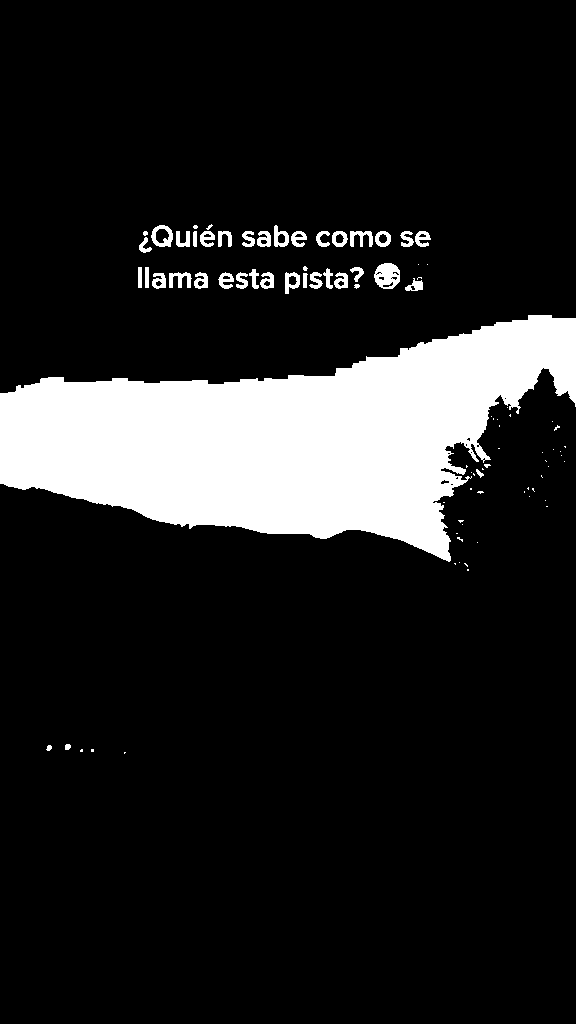

In [81]:
# Preprocessing: Convert to grayscale for better OCR accuracy
gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
_, thresh_frame = cv2.threshold(gray_frame, 150, 255, cv2.THRESH_BINARY)
nb_imshow(thresh_frame)

In [84]:
# Extract text using Tesseract
extracted_text = pytesseract.image_to_string(thresh_frame, config='--psm 11')
extracted_text

'éQuién sabe como se\n\nllama esta pista? ® 4\n\noe\n'

In [85]:
clean_text = extracted_text.strip()

# Return None if the string is empty, otherwise return the text
if len(clean_text) != 0:
    text = clean_text.replace('\n', ' ')

text

'éQuién sabe como se  llama esta pista? ® 4  oe'

### Text evaluation

In [137]:
def setup_catchiness_model():
    """
    Downloads and loads the multilingual zero-shot model into the local CPU.
    """
    print("Loading Multilingual Zero-Shot Classifier on CPU...")
    # device=-1 explicitly tells Hugging Face to use the CPU instead of a GPU
    classifier = pipeline(
        "zero-shot-classification", 
        model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli", 
        device=-1 
    )
    return classifier

def get_catchiness_score(text, classifier):
    """
    Evaluates the text and returns a float (0.0 to 1.0) representing 
    the model's confidence that the text is a catchy hook.
    """
    # Guard against empty text or None. Return 0.0 confidence.
    if not text or not isinstance(text, str) or len(text.strip()) < 2:
        return 0.0

    target_label = "shocking, clickbait, or highly emotional"
    candidate_labels = [
        target_label, 
        "plain, boring, or simply descriptive"
    ]
    
    try:
        # Run inference
        result = classifier(text, candidate_labels, multi_label=False)
        
        # Find exactly where our target label ended up in the sorted results
        target_index = result['labels'].index(target_label)
        
        # Extract the corresponding confidence score for that label
        catchiness_score = result['scores'][target_index]
        
        # Return rounded to 4 decimal places for clean data
        return round(catchiness_score, 4)
            
    except Exception as e:
        print(f"Classification error on text '{text}': {e}")
        return 0.0

In [138]:
catchy_model = setup_catchiness_model()

# Test cases in multiple languages
test_strings = [
    "No one expected that!!",                  # English: Should be high
    "Monday morning mood",                     # English: Should be low
    "Il n'y a AUCUN moyen que ça marche...",   # French: Should be high
    "Receta de pastel de manzana",             # Spanish: Should be low
    "HOW??!!!"                                 # Universal: Should be high
]

print("\n--- Hook Confidence Scores ---")
for string in test_strings:
    score = get_catchiness_score(string, catchy_model)
    print(f"Score: {score:.4f} | Text: '{string}'")

Loading Multilingual Zero-Shot Classifier on CPU...


Cancellation requested; stopping current tasks.


KeyboardInterrupt: 

## Optical Flow (Motion Vectors)

<div class='alert alert-warning'>

This section needs a GPU enabled with **NVIDIA's Hardware Optical Flow Accelerator (NVOFA)**.

Examples:
- Turing architecture (or newer)
- RTX 20, 30, or 40 series

</div>

Calculate dense optical flow between frames in the first two seconds. By averaging the magnitude of motion vectors across these frames, you get a "Motion Score." A high score indicates immediate physical action (e.g., someone dancing, falling, or running right away); a low score indicates a "talking head" or a slow pan.

**Optical Flow** (specifically Dense Optical Flow, like the Farneback algorithm in OpenCV) doesn't just subtract pixels in place; it **looks for patterns** (edges, textures) in Frame A and actively searches for **where those exact patterns shifted to** in Frame B.

**How it "sees" the world:**

If there is a video of a red ball moving left:

* In Frame 1, it identifies the edge of the red ball.
* In Frame 2, it searches the nearby area, finds that same red edge, and calculates a mathematical **vector** (magnitude and direction).
* **The Optical Flow Score** says: *"That specific red cluster moved 15 pixels to the right at an angle of 0 degrees. Score: High movement."*

**What it misses:**
Optical Flow gets incredibly confused by hard camera cuts. If Frame A is a shot of a dog, and Frame B is a shot of a skyscraper, the algorithm panics because it can't find the "dog pixels" anywhere in the new frame. It outputs garbage noise.

In [ ]:
import os
import glob
import torch
from tqdm import tqdm
import nvidia.dali.fn as fn
from nvidia.dali.pipeline import Pipeline
from nvidia.dali.plugin.pytorch import DALIGenericIterator, LastBatchPolicy

def create_dali_pipeline(video_files, batch_size=4, sequence_length=60):
    """
    Defines the DALI computation graph.
    """
    # Initialize the pipeline
    pipe = Pipeline(batch_size=batch_size, num_threads=4, device_id=0)

    with pipe:
        # Decode Video, sequence_length=60 assumes 2 seconds at 30 FPS.
        # pad_sequences=True ensures videos slightly shorter than 60 frames don't crash.
        video = fn.readers.video(
            device="gpu",
            filenames=video_files,
            sequence_length=sequence_length,
            step=1,              # Force consecutive frame reading
            stride=1,            # Don't skip any frames internally
            shard_id=0,
            num_shards=1,
            pad_sequences=True,
            random_shuffle=False,
            name="VideoReader"
        )

        # Force every frame to 720x1280 (standard vertical)
        # This ensures the Width and Height are uniform across the batch to stack into Dense Tensors
        video_resized = fn.resize(video, resize_x=720, resize_y=1280)

        # Calculate Optical Flow
        # We use a preset quality of 0.0 (fastest) to 1.0 (highest quality).
        flow = fn.optical_flow(video_resized, device="gpu", preset=0.5)

        # Define what the pipeline should output to PyTorch
        pipe.set_outputs(flow)

    return pipe

def extract_motion_features(video_folder, batch_size=4):
    """
    Runs the pipeline and calculates the final motion scores using PyTorch.
    """
    # Grab all trimmed MP4s
    video_files = sorted(glob.glob(os.path.join(video_folder, "*.mp4")))
    if not video_files:
        print("No videos found in the directory.")
        return []

    print(f"Found {len(video_files)} videos. Initializing GPU Pipeline...")

    # Build the DALI pipeline
    pipeline = create_dali_pipeline(video_files, batch_size=batch_size)
    pipeline.build()

    # Create a PyTorch iterator to consume the DALI output
    # reader_name must match the name given to fn.readers.video
    dali_iter = DALIGenericIterator(
        [pipeline],
        ['flow'],
        reader_name="VideoReader",
        last_batch_policy=LastBatchPolicy.PARTIAL,
        auto_reset=True
    )

    results = []
    video_index = 0

    # Iterate through the batches
    with tqdm(total=len(video_files), desc="Processing Hooks") as pbar:
      for batch in dali_iter:
          # The flow tensor shape is: (Batch_Size, Sequence_Length, Height, Width, 2)
          # The '2' at the end represents the X and Y movement vectors.
          flow_tensor = batch[0]['flow']

          for i in range(flow_tensor.shape[0]):  # Loop through videos in the batch
              if video_index >= len(video_files):
                  break

              single_video_flow = flow_tensor[i] # Shape: (Seq, H, W, 2)

              # Calculating Magnitude
              # Optical flow gives us vectors: (v_x, v_y)

              x_movement = single_video_flow[..., 0]
              y_movement = single_video_flow[..., 1]

              magnitude = torch.sqrt(x_movement**2 + y_movement**2)

              # Calculate the average motion per frame, then max motion across the sequence
              frame_avg_motion = torch.mean(magnitude, dim=[1, 2]) # Average across Height and Width

              # Extract features for your ML model
              max_motion_spike = torch.max(frame_avg_motion).item()
              avg_overall_motion = torch.mean(frame_avg_motion).item()

              results.append({
                  'video_id': os.path.basename(video_files[video_index]),
                  'max_motion_spike': round(max_motion_spike, 3),
                  'avg_overall_motion': round(avg_overall_motion, 3)
              })

              video_index += 1
              pbar.update(1) # Move the bar forward by 1 video

          if video_index >= len(video_files):
              break
                
    # Free up the T4 GPU memory before returning the results
    del dali_iter
    del pipeline

    return results

In [ ]:
# Run the extraction (adjust batch_size based on your T4's VRAM; 4 or 8 is safe)
motion_metrics = extract_motion_features(TRIMMED_HOOKS_FOLDER, batch_size=4)

In [41]:
motion_df = pd.read_csv('hook_motion_features.csv', header=0)
motion_df.dtypes

video_id                int64
max_motion_spike      float64
avg_overall_motion    float64
dtype: object

In [42]:
df = df.merge(motion_df, left_on='id', right_on='video_id', how='left').drop(columns=['video_id'])

In [43]:
df

,id,filepath,split,max_spike,avg_volatility,max_motion_spike,avg_overall_motion
0,7602656035161050390,data/videos_mp4/USER_davosklosters/VIDEO_76026...,train,6.204138,4.442986,132.394,5.629
1,7590718903144287510,data/videos_mp4/USER_davosklosters/VIDEO_75907...,train,69.816795,6.330782,192.246,3.378
2,7571821778746592534,data/videos_mp4/USER_davosklosters/VIDEO_75718...,train,29.082718,2.700911,2.309,1.078
3,7569927329154190614,data/videos_mp4/USER_davosklosters/VIDEO_75699...,train,1.286115,0.903864,2.314,1.030
4,7566270741134462230,data/videos_mp4/USER_davosklosters/VIDEO_75662...,train,17.086381,15.656680,2.314,1.087
...,...,...,...,...,...,...,...
1681,7322420132649749793,data/videos_mp4/USER_baqueiraberetoficial/VIDE...,test,7.207402,4.323529,119.369,5.014
1682,7321436866287373600,data/videos_mp4/USER_baqueiraberetoficial/VIDE...,test,18.688947,3.831430,119.369,5.285
1683,7312523032025730337,data/videos_mp4/USER_baqueiraberetoficial/VIDE...,test,48.867405,5.476881,119.369,8.303
1684,7305425778076880161,data/videos_mp4/USER_baqueiraberetoficial/VIDE...,test,1.173783,0.983592,22.177,0.544


In [139]:
df.to_csv('final_hook_features.csv', index=False)

## Extras

### Why use both Content Score Volatility and Optical flow in a ML model

Because these algorithms have blind spots, they complement each other perfectly when evaluating a short-form video hook. Your model will learn to cross-reference them:

* **High Volatility + Low Optical Flow:** The model learns this is likely a **Hard Cut, a Flash, or a Text pop-up**. (Lots of pixels changed color instantly, but nothing is actually "moving" across the screen).
* **Low Volatility + High Optical Flow:** The model learns this is **Fast Action on a static background**. (e.g., A creator running past a tripod camera. The background pixels stayed the same color, so volatility is low, but the Optical Flow tracked the creator moving incredibly fast).
* **High Volatility + High Optical Flow:** The model learns this is **Shaky Cam / Extreme Action**. The camera is moving rapidly, meaning every single pixel is shifting direction *and* changing color constantly.

### Unused functions

In [ ]:
def calculate_hook_cuts(video_path):
    """
    Calculates the number of scene cuts in a video.
    Returns an integer representing the edit frequency.
    """
    try:
        video = open_video(video_path)
        scene_manager = SceneManager()
        
        # Add the ContentDetector
        # The threshold determines how much the content must change to trigger a cut.
        scene_manager.add_detector(ContentDetector(threshold=27.0))
        
        # Process the video
        scene_manager.detect_scenes(video)
        scene_list = scene_manager.get_scene_list()
        
        # Skip the very first "scene" (which just represents the start of the video at 0.0s)
        cuts_in_hook = len(scene_list) - 1
        
        return cuts_in_hook

    except Exception as e:
        print(f"Error processing {video_path}: {e}")
        return 0

# Valence and Arousal

Maps the audio to [Russell's Circumplex Model of Affect](https://pdodds.w3.uvm.edu/research/papers/others/1980/russell1980a.pdf) (the Valence-Arousal space).

## Notes on the meaning of this theory

The model we used is based on the **VAD (Valence-Arousal-Dominance) Dimensional Model of Emotion**, first developed by psychologist Albert Mehrabian.

Instead of classifying emotions into rigid boxes (like "happy" or "angry"), the VAD model maps emotions as continuous coordinates in a 3D space.

### 1. Valence (The Positivity Axis)

Valence measures the intrinsic attractiveness (pleasantness) or aversiveness (unpleasantness) of a stimulus.

* **High Valence (+1.0):** Joy, excitement, love, triumph.
* **Low Valence (-1.0):** Disgust, sadness, anger, fear.
* **Zero (0.0):** Neutral, objective reporting.

**How it is calculated from audio:**
Valence is famously the hardest dimension for machines to calculate from audio alone. Neural networks look for:

* **Harmonic Structure:** In music, major keys versus minor keys.
* **Pitch Contours:** A rising intonation at the end of a sentence or a "bouncy" pitch contour often indicates positive valence.
* **Formant Shifts:** When humans smile, the physical shape of the vocal tract changes, subtly shifting resonant frequencies (formants). Deep learning models (like wav2vec2) are sensitive enough to detect these acoustic signatures of a "smiling voice."

### 2. Arousal (The Energy Axis)

Arousal measures the level of physical and psychological activation or intensity.

* **High Arousal (+1.0):** Panic, frantic excitement, rage, terror.
* **Low Arousal (-1.0):** Sleepiness, boredom, extreme calm, lethargy.
* **Zero (0.0):** Awake but relaxed.

**How it is calculated from audio:**
Arousal is the easiest dimension for a machine to calculate because it is highly correlated with raw physical energy.

* **Loudness (RMS/Amplitude):** High volume and sudden dynamic shifts strongly indicate high arousal.
* **Pacing (Tempo/Speech Rate):** Fast-talking, rapid beats, or a high number of syllables per second drive the arousal score up.
* **High-Frequency Energy:** Shouting or screaming introduces aggressive high-frequency friction into the audio wave, which models heavily weight for high arousal.

### 3. Dominance (The Control Axis)

Dominance measures the feeling of control, power, and influence over a situation versus feeling submissive, controlled, or vulnerable.

* **High Dominance (+1.0):** Anger, pride, authoritative commands, aggressive confidence.
* **Low Dominance (-1.0):** Fear, sadness, awe, submission, pleading.

**How it is calculated from audio:**
Dominance shares some acoustic traits with Arousal, but differentiates itself by looking for "vocal weight" and authority.

* **Low-Frequency Emphasis:** A deeper, steady pitch with strong low-frequency energy implies size and authority (think of a strict teacher giving an order versus someone screaming in panic).
* **Vocal Effort:** Pushing more air from the diaphragm (even if not strictly "loud") changes the spectral tilt of the audio.
* **Pausological Features:** Deliberate pacing with firm, unhesitating pauses implies control (high dominance), whereas stuttering, breathiness, or erratic pauses imply vulnerability (low dominance).

---

### How the AI Actually Generates the Final Number

When you run your MP4 audio through the `wav2vec2` model, it isn't literally calculating a mathematical formula of volume + pitch = arousal.

Instead, the model calculates these scores through **supervised regression learning**:

1. **Human Ground Truth:** Researchers gathered tens of thousands of audio clips (podcasts, movies, natural conversations). They had thousands of human listeners rate each clip using a visual tool called the Self-Assessment Manikin (SAM).
2. **Neural Network:** When you feed an audio to the model, it breaks the audio into tiny 20-millisecond slices, extracts the acoustic embeddings, and outputs a continuous floating-point number (e.g., `0.75 Valence, 0.82 Arousal, 0.40 Dominance`) that represents where human listeners would most likely plot that specific sound on the 3D VAD graph.

The audEERING `wav2vec2` model outputs three specific coordinates (Valence, Arousal, and Dominance), which means it is natively outputting the 3D space of the **VAD model** (originally called the PAD model: Pleasure-Arousal-Dominance), rather than strictly the 2D space of **Russell's Circumplex Model**.

However, here is the fun historical twist: they aren't competing theories!

### The Connection Between the Two Models

1. **The 3D Origin (1974):** Albert Mehrabian and James Russell actually worked *together* to create the 3D PAD (Pleasure/Valence, Arousal, Dominance) model to explain how environments affect human emotion.
2. **The 2D Evolution (1980):** A few years later, James Russell published his famous "Circumplex Model of Affect." He realized that while Dominance is real, **Valence and Arousal account for the vast majority of the variance** in how we categorize emotions. Dominance was often harder to measure, so Russell simplified the model into a 2D circle (the Circumplex) that is much easier to map mathematically.